In [2]:
import pandas as pd

movies = pd.read_csv('../data/movies.csv')
ratings = pd.read_csv('../data/ratings.csv')
links = pd.read_csv('../data/links.csv')
tags = pd.read_csv('../data/tags.csv')

tmdb = pd.read_csv('../data/tmdb_5000_movies.csv')

In [3]:
print(movies.head())
print(ratings.head())
print(links.head())
print(tmdb.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
   movieId  imdbId   tmdbId
0        1  114709    862.0
1        2  113497   8844.0
2        3  113228  15602.0
3        4  114885  31357.0
4        5  113041  11862.0
      bud

In [4]:
data = pd.merge(ratings, movies, on='movieId')
print(data.head())

   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  


In [5]:
links = links.dropna()
links['tmdbId'] = links['tmdbId'].astype(int)

In [6]:
tmdb = tmdb.rename(columns={'id': 'tmdbId'})

merged = pd.merge(links, tmdb, on='tmdbId')
print(merged.head())

   movieId  imdbId  tmdbId    budget  \
0        1  114709     862  30000000   
1       10  113189     710  58000000   
2       11  112346    9087  62000000   
3       14  113987   10858  44000000   
4       15  112760    1408  98000000   

                                              genres  \
0  [{"id": 16, "name": "Animation"}, {"id": 35, "...   
1  [{"id": 12, "name": "Adventure"}, {"id": 28, "...   
2  [{"id": 35, "name": "Comedy"}, {"id": 18, "nam...   
3  [{"id": 36, "name": "History"}, {"id": 18, "na...   
4  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage  \
0          http://toystory.disney.com/toy-story   
1  http://www.mgm.com/view/movie/757/Goldeneye/   
2                                           NaN   
3                                           NaN   
4                                           NaN   

                                            keywords original_language  \
0  [{"id": 931, "name": "jealousy"}, {"id

In [7]:
print(data.shape)
print(data.columns)

(100836, 6)
Index(['userId', 'movieId', 'rating', 'timestamp', 'title', 'genres'], dtype='object')


In [8]:
top_movies = data.groupby('title')['rating'].mean().sort_values(ascending=False).head(10)
print(top_movies)

title
Karlson Returns (1970)                                                         5.0
Zeitgeist: Moving Forward (2011)                                               5.0
Dream of Light (a.k.a. Quince Tree Sun, The) (Sol del membrillo, El) (1992)    5.0
Dragons: Gift of the Night Fury (2011)                                         5.0
12 Angry Men (1997)                                                            5.0
Justice League: Doom (2012)                                                    5.0
Junior and Karlson (1968)                                                      5.0
Jump In! (2007)                                                                5.0
Human Condition III, The (Ningen no joken III) (1961)                          5.0
Louis Theroux: Law & Disorder (2008)                                           5.0
Name: rating, dtype: float64


In [9]:
popular_movies = data.groupby('title')['rating'].count().sort_values(ascending=False).head(10)
print(popular_movies)

title
Forrest Gump (1994)                          329
Shawshank Redemption, The (1994)             317
Pulp Fiction (1994)                          307
Silence of the Lambs, The (1991)             279
Matrix, The (1999)                           278
Star Wars: Episode IV - A New Hope (1977)    251
Jurassic Park (1993)                         238
Braveheart (1995)                            237
Terminator 2: Judgment Day (1991)            224
Schindler's List (1993)                      220
Name: rating, dtype: int64


In [10]:
movie_stats = data.groupby('title').agg({
    'rating': ['mean', 'count']
})

movie_stats.columns = ['avg_rating', 'num_ratings']
movie_stats = movie_stats.sort_values(by='num_ratings', ascending=False)

print(movie_stats.head(10))

                                           avg_rating  num_ratings
title                                                             
Forrest Gump (1994)                          4.164134          329
Shawshank Redemption, The (1994)             4.429022          317
Pulp Fiction (1994)                          4.197068          307
Silence of the Lambs, The (1991)             4.161290          279
Matrix, The (1999)                           4.192446          278
Star Wars: Episode IV - A New Hope (1977)    4.231076          251
Jurassic Park (1993)                         3.750000          238
Braveheart (1995)                            4.031646          237
Terminator 2: Judgment Day (1991)            3.970982          224
Schindler's List (1993)                      4.225000          220


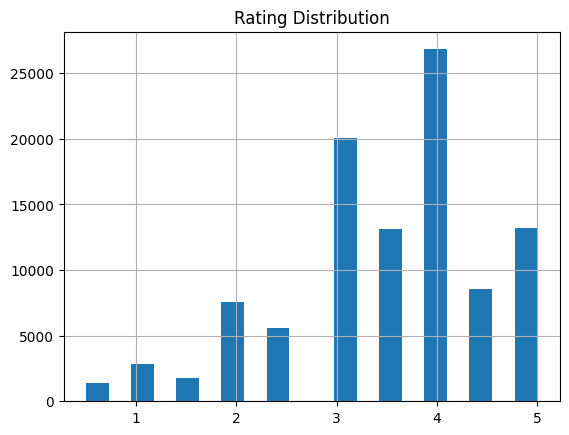

In [11]:
import matplotlib.pyplot as plt

data['rating'].hist(bins=20)
plt.title("Rating Distribution")
plt.show()

In [12]:
active_users = data.groupby('userId')['rating'].count().sort_values(ascending=False)
print(active_users.head(10))

userId
414    2698
599    2478
474    2108
448    1864
274    1346
610    1302
68     1260
380    1218
606    1115
288    1055
Name: rating, dtype: int64


In [13]:
movies['genres'].str.split('|').explode().value_counts().head(10)

genres
Drama        4361
Comedy       3756
Thriller     1894
Action       1828
Romance      1596
Adventure    1263
Crime        1199
Sci-Fi        980
Horror        978
Fantasy       779
Name: count, dtype: int64

In [14]:
tmdb = tmdb[['title', 'overview']].dropna()
print(tmdb.head())

                                      title  \
0                                    Avatar   
1  Pirates of the Caribbean: At World's End   
2                                   Spectre   
3                     The Dark Knight Rises   
4                               John Carter   

                                            overview  
0  In the 22nd century, a paraplegic Marine is di...  
1  Captain Barbossa, long believed to be dead, ha...  
2  A cryptic message from Bond’s past sends him o...  
3  Following the death of District Attorney Harve...  
4  John Carter is a war-weary, former military ca...  


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(tmdb['overview'])

In [16]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [17]:
indices = pd.Series(tmdb.index, index=tmdb['title']).drop_duplicates()

In [18]:
def recommend(movie_title):
    idx = indices[movie_title]
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    sim_scores = sim_scores[1:6]  # top 5
    
    movie_indices = [i[0] for i in sim_scores]
    
    return tmdb['title'].iloc[movie_indices]

In [27]:
recommend("Spider-Man")

5                   Spider-Man 3
38      The Amazing Spider-Man 2
20        The Amazing Spider-Man
30                  Spider-Man 2
1534               Arachnophobia
Name: title, dtype: object